In [1]:
%matplotlib widget
import scipp as sc
import tof

source = tof.Source(facility="ess", neutrons=1_000_000)
da = source.data.squeeze()
da.hist(birth_time=200, wavelength=500).plot(
    cmap="jet", 
    xmin=sc.scalar(0, unit="Å"), 
    xmax=sc.scalar(5, unit="Å"), 
    grid=True,
)

# x = source.data.coords["birth_time"].values[0]
# y = source.data.coords["wavelength"].values[0]
# xedges = np.linspace(0, 4500, 100)
# yedges = np.linspace(0, 6, 100)
# H, xedges, yedges = np.histogram2d(x, y, bins=(xedges, yedges))

# fig, ax = plt.subplots()
# ax.pcolormesh(xedges, yedges, H.T, cmap="jet")
# ax.set_xlabel(f"Birth time [{source.data.coords['birth_time'].unit}]")
# ax.set_ylabel(f"Wavelength [{source.data.coords['wavelength'].unit}]")
# ax.set_title("ESS Source Neutron Birth Time vs Wavelength")
# ax.grid(alpha=0.6)
# plt.show(fig)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

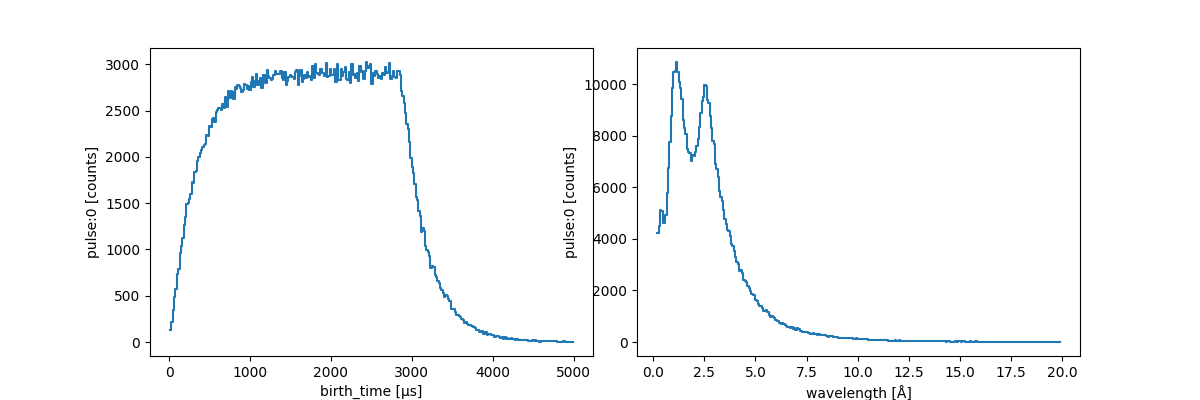

In [2]:
source = tof.Source(facility="ess", neutrons=500_000)
source.plot()

In [7]:
import scipp as sc
from trex.source import Source
from trex.instrument import Instrument

central_wavelength = sc.scalar(2.5, unit="Å")
rrm: int = 8  # repetition rate multiplication factor
T_OFFSET = sc.scalar(1.7, unit="ms")
trex = Instrument(wavelength=central_wavelength, rrm=rrm, t_offset=T_OFFSET)
mask = trex.mask_from_chopper("Monochromatic Chopper 2")
# mask = trex.mask_from_chopper("Bandwidth Chopper 2")

source = Source(facility="ess", neutrons=1_000_000)
source.apply_mask(mask)
print(source.data)

<scipp.DataArray>
Dimensions: Sizes[pulse:1, event:1000000, ]
Coordinates:
* birth_time                float64            [µs]  (pulse, event)  [781.495, 2871.82, ..., 3055.66, 1968.44]
* distance                  float64              [m]  ()  0
* eto                       float64            [µs]  (pulse, event)  [781.495, 2871.82, ..., 3055.66, 1968.44]
* id                          int64        <no unit>  (pulse, event)  [0, 1, ..., 999998, 999999]
* speed                     float64            [m/s]  (pulse, event)  [2382.65, 1638.55, ..., 1466.84, 3522.27]
* toa                       float64            [µs]  (pulse, event)  [781.495, 2871.82, ..., 3055.66, 1968.44]
* wavelength                float64             [Å]  (pulse, event)  [1.66035, 2.41435, ..., 2.69697, 1.12315]
Data:
                            float64         [counts]  (pulse, event)  [1, 1, ..., 1, 1]
Masks:
  mask                         bool        <no unit>  (pulse, event)  [True, True, ..., True, True]




In [8]:
da = source.data.squeeze()
da.hist(birth_time=500, wavelength=2000).plot(
    cmap="jet",
    xmin=sc.scalar(1.5, unit="Å"),
    xmax=sc.scalar(3.5, unit="Å"),
    grid=True,
    ymin=sc.scalar(0.0, unit="ms"),
    ymax=sc.scalar(4, unit="ms"),
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…